In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/User/Desktop/Data_Science/Iris.csv")

In [3]:
df = df.iloc[: , 1:]

In [4]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
encoder = LabelEncoder()

In [7]:
df['Species'] = encoder.fit_transform(df['Species'])

In [8]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']] ## we dropped setosa because it is easily classify as it exist as a totally different class in data

In [10]:
df

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


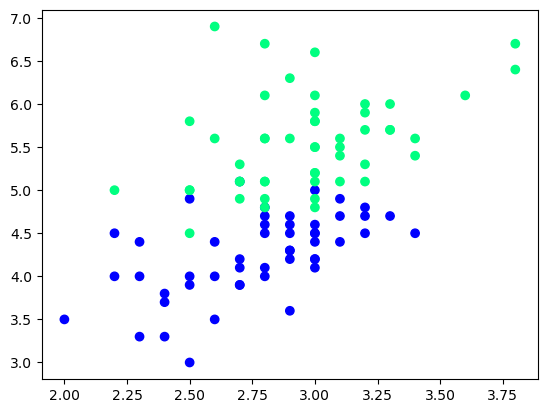

In [11]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')
plt.show()

# **`Applying Bagging on bootstrapped Data`**

In [12]:
# take out 10 samples for training of model 

df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
108,2.5,5.8,2
77,3.0,5.0,1
66,3.0,4.5,1
98,2.5,3.0,1
104,3.0,5.8,2
92,2.6,4.0,1
64,2.9,3.6,1
106,2.5,4.5,2
88,3.0,4.1,1


In [13]:
# Taking only 10 rows for training
df = df.sample(100) # idea here to shuffle the rows of data
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_val

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
94,2.7,4.2,1
148,3.4,5.4,2
117,3.8,6.7,2
72,2.5,4.9,1


In [15]:
X_test = df_val.iloc[: , 0:2].values
y_test = df_val.iloc[: , -1].values

# **`Bagging`**

In [16]:
df_bag = df_train.sample(8 , replace = True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
88,3.0,4.1,1
73,2.8,4.7,1
76,2.8,4.8,1
77,3.0,5.0,1
91,3.0,4.6,1
110,3.2,5.1,2
77,3.0,5.0,1


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [18]:
dt_bag1 = DecisionTreeClassifier()

In [19]:
def evaluate(clf  ,X , y):
    clf.fit(X ,y )
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values , y.values , clf = clf , legend = 2)
    y_pred = clf.predict(X_test)
    print("Acuracy Score ----------------------------> " ,accuracy_score(y_test , y_pred))

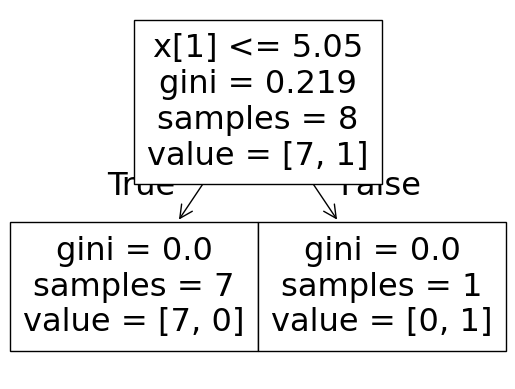

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Acuracy Score ---------------------------->  1.0


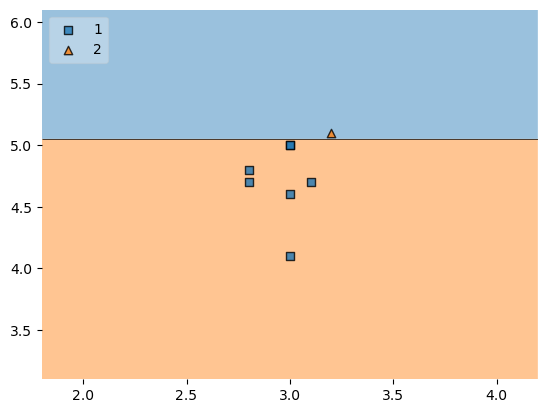

In [20]:
evaluate(dt_bag1 , X , y)

In [21]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
110,3.2,5.1,2
112,3.0,5.5,2
82,2.7,3.9,1
76,2.8,4.8,1
88,3.0,4.1,1
73,2.8,4.7,1
76,2.8,4.8,1
73,2.8,4.7,1


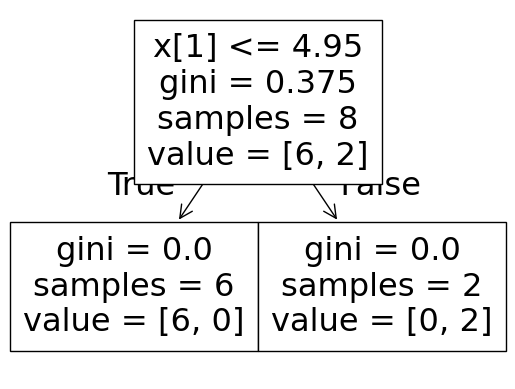

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Acuracy Score ---------------------------->  1.0


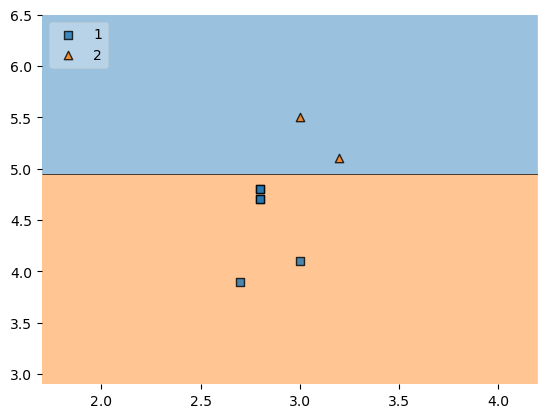

In [22]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2 , X , y)

In [23]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
112,3.0,5.5,2
77,3.0,5.0,1
76,2.8,4.8,1
91,3.0,4.6,1
88,3.0,4.1,1
73,2.8,4.7,1
76,2.8,4.8,1


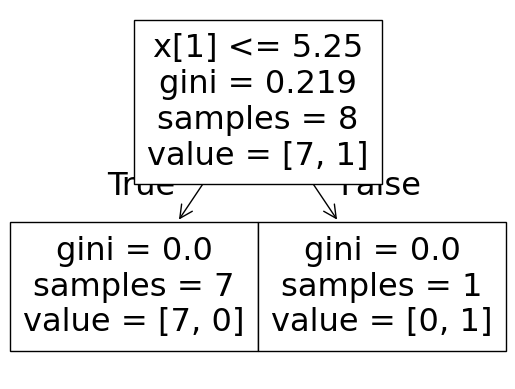

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Acuracy Score ---------------------------->  1.0


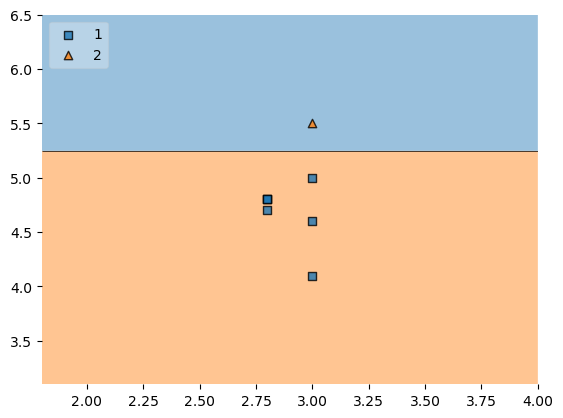

In [24]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3 , X , y)

In [26]:
df_test ## this is the unseen data which our model has not seen ever 

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
139,3.1,5.4,2
70,3.2,4.8,1
101,2.7,5.1,2
51,3.2,4.5,1


In [28]:
print("Predictor 1",dt_bag1.predict(np.array([3.1,5.4]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.1,5.4]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.1,5.4]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **`Pasting`**

In [29]:
df_train


,SepalWidthCm,PetalLengthCm,Species
112,3.0,5.5,2
144,3.3,5.7,2
82,2.7,3.9,1
91,3.0,4.6,1
88,3.0,4.1,1
86,3.1,4.7,1
77,3.0,5.0,1
73,2.8,4.7,1
110,3.2,5.1,2
76,2.8,4.8,1


In [31]:
df_train.sample(8) ## replace = False

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
91,3.0,4.6,1
76,2.8,4.8,1
144,3.3,5.7,2
110,3.2,5.1,2
77,3.0,5.0,1
112,3.0,5.5,2
73,2.8,4.7,1


# **`Random Subspaces`**

In [33]:
df1 = pd.read_csv("C:/Users/User/Desktop/Data_Science/Iris.csv")

In [43]:
df1.sample(2 , axis = 1 )

,SepalLengthCm,SepalWidthCm
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


# **`Random Patches`**

In [45]:
df1.sample(150)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
19,20,5.1,3.8,1.5,0.3,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
32,33,5.2,4.1,1.5,0.1,Iris-setosa
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
145,146,6.7,3.0,5.2,2.3,Iris-virginica
...,...,...,...,...,...,...
26,27,5.0,3.4,1.6,0.4,Iris-setosa
116,117,6.5,3.0,5.5,1.8,Iris-virginica
55,56,5.7,2.8,4.5,1.3,Iris-versicolor
34,35,4.9,3.1,1.5,0.1,Iris-setosa


In [50]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalWidthCm,SepalWidthCm
99,1.3,2.8
94,1.3,2.7
21,0.4,3.7
125,1.8,3.2
111,1.9,2.7
27,0.2,3.5
124,2.1,3.3
99,1.3,2.8
